In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB7
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix
from PIL import ImageFile




In [ ]:
data_dir = "ambulance_data"
img_size = 224  # EfficientNetB7 default size is 600, but 224 is lighter for GPU
batch_size = 16


In [ ]:
# Processing the data
import os
from PIL import Image, ImageFilter
import shutil

source_dir = "ambulance_data"
target_dir = "processed_data"
target_size = (224, 224)

if not os.path.exists(target_dir):
    os.makedirs(target_dir)

for category in ['ambulance', 'non_ambulance']:
    src_folder = os.path.join(source_dir, category)
    tgt_folder = os.path.join(target_dir, category)
    os.makedirs(tgt_folder, exist_ok=True)

    for i, file in enumerate(os.listdir(src_folder)):
        src_path = os.path.join(src_folder, file)
        tgt_path = os.path.join(tgt_folder, f"{category}_{i:04d}.jpg")

        try:
            with Image.open(src_path) as img:
                img = img.convert('RGB')  # convert to RGB
                img = img.resize(target_size)
                # Optional: remove blurry images
                if img.filter(ImageFilter.FIND_EDGES).getbbox():
                    img.save(tgt_path)
        except Exception as e:
            print(f"Skipped: {src_path} due to {e}")


In [ ]:
# Spliting the data
import os
import shutil
import random

def split_dataset(input_dir, output_dir, split_ratio=0.8):
    categories = ['ambulance', 'non_ambulance']

    for category in categories:
        img_folder = os.path.join(input_dir, category)
        images = os.listdir(img_folder)
        random.shuffle(images)

        train_len = int(len(images) * split_ratio)
        train_imgs = images[:train_len]
        val_imgs = images[train_len:]

        # Make dirs
        train_folder = os.path.join(output_dir, 'train', category)
        val_folder = os.path.join(output_dir, 'val', category)
        os.makedirs(train_folder, exist_ok=True)
        os.makedirs(val_folder, exist_ok=True)

        # Copy images
        for img in train_imgs:
            shutil.copy(os.path.join(img_folder, img), os.path.join(train_folder, img))
        for img in val_imgs:
            shutil.copy(os.path.join(img_folder, img), os.path.join(val_folder, img))

        print(f"{category}: {len(train_imgs)} train, {len(val_imgs)} val")

split_dataset("processed_data", "split_data", split_ratio=0.8)


ambulance: 455 train, 114 val
non_ambulance: 424 train, 106 val


In [20]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# Define paths
train_path = 'split_data/train'
val_path = 'split_data/val'

# Image preprocessing
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=(0.8, 1.2)
)

val_datagen = ImageDataGenerator(rescale=1./255)

# Create generators
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

val_generator = val_datagen.flow_from_directory(
    val_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

# Load EfficientNetB0 base
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze base layers

# Add custom classification layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.2)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)





Found 879 images belonging to 2 classes.
Found 220 images belonging to 2 classes.


In [21]:
base_model.trainable = True  # Allow full model training


In [22]:
model.compile(optimizer=Adam(1e-5), loss='binary_crossentropy', metrics=['accuracy'])


In [16]:
ImageFile.LOAD_TRUNCATED_IMAGES = True

In [23]:

# Train model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
28/28 [==============================] - 74s 2s/step - loss: 0.6946 - accuracy: 0.5199 - val_loss: 0.7057 - val_accuracy: 0.4818
Epoch 2/10
28/28 [==============================] - 60s 2s/step - loss: 0.6405 - accuracy: 0.6633 - val_loss: 0.7009 - val_accuracy: 0.4818
Epoch 3/10
28/28 [==============================] - 58s 2s/step - loss: 0.5964 - accuracy: 0.7201 - val_loss: 0.7119 - val_accuracy: 0.4818
Epoch 4/10
28/28 [==============================] - 55s 2s/step - loss: 0.5559 - accuracy: 0.7861 - val_loss: 0.7326 - val_accuracy: 0.4773
Epoch 5/10
28/28 [==============================] - 55s 2s/step - loss: 0.5205 - accuracy: 0.8453 - val_loss: 0.7318 - val_accuracy: 0.2636
Epoch 6/10
28/28 [==============================] - 54s 2s/step - loss: 0.4741 - accuracy: 0.8726 - val_loss: 0.7246 - val_accuracy: 0.3500
Epoch 7/10
28/28 [==============================] - 62s 2s/step - loss: 0.4360 - accuracy: 0.8749 - val_loss: 0.7277 - val_accuracy: 0.3864
Epoch 8/10
28/28 [==

KeyboardInterrupt: 

In [18]:
print(train_generator.class_indices)


{'ambulance': 0, 'non_ambulance': 1}


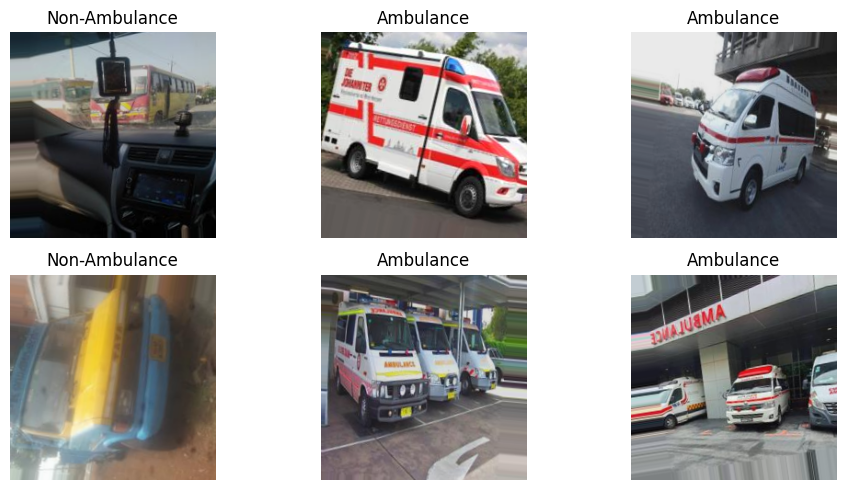

In [19]:
images, labels = next(train_generator)
plt.figure(figsize=(10, 5))
for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.imshow(images[i])
    plt.title("Ambulance" if labels[i] == 0 else "Non-Ambulance")
    plt.axis('off')
plt.tight_layout()
plt.show()
